# 05 - Model Evaluation, Hyperparameter Tuning & Cross-Validation
## Online Shoppers Purchasing Intention Dataset

**Goal of this notebook:**
In `04_Model_Training.ipynb` we trained 6 baseline models (single train/test split)
and identified promising candidates. A single train/test split can be noisy - the
particular random split we happened to use could make a model look better or worse
than it really is. In this final notebook we will:

1. Load the final engineered data and the baseline models/results from Notebook 04.
2. Run **Stratified K-Fold Cross-Validation** on all 6 baseline configurations to get
   robust, split-independent performance estimates.
3. Select the most promising model/strategy combination(s) based on CV results.
4. Perform **Hyperparameter Tuning** using `RandomizedSearchCV` (efficient search over
   a large parameter space) for our top candidate(s).
5. Refit the best-found model and perform a **thorough final evaluation** on the
   held-out test set (classification report, confusion matrix, ROC/PR curves).
6. Explore **decision threshold tuning** (since 0.5 is not always the optimal cutoff
   for an imbalanced problem).
7. Save the final tuned model - ready to be used in a production pipeline (VS Code).

> **Why Cross-Validation AFTER already seeing baseline test results?** This is a
> common and valid workflow: baseline single-split results (Notebook 04) help us
> quickly narrow down from 6 candidates to the most promising 1-2. Then we invest
> the extra compute cost of K-Fold CV + hyperparameter search only on those
> candidates, rather than on all 6, saving time while still being rigorous about the
> final model choice.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score, f1_score, precision_score, recall_score,
    roc_curve, precision_recall_curve, make_scorer
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

RANDOM_STATE = 42

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Data and Baseline Results (outputs of Notebooks 03 & 04)

In [2]:
X_train = pd.read_csv('../data/processed/X_train_fe.csv')
X_test = pd.read_csv('../data/processed/X_test_fe.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

baseline_results = pd.read_csv('../data/processed/model_comparison_results.csv')

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print()
print("Baseline results from Notebook 04 (sorted by F1-Score):")
baseline_results.sort_values('F1_Score', ascending=False).reset_index(drop=True)


X_train shape: (9764, 38)
X_test shape:  (2441, 38)

Baseline results from Notebook 04 (sorted by F1-Score):


,Model,Precision,Recall,F1_Score,ROC_AUC,PR_AUC
0,LightGBM_ClassWeight,0.614072,0.753927,0.676851,0.929274,0.737486
1,RandomForest_SMOTE,0.635071,0.701571,0.666667,0.923992,0.710042
2,LightGBM_SMOTE,0.652284,0.672775,0.662371,0.930127,0.739942
3,XGBoost_ClassWeight,0.622596,0.678010,0.649123,0.918605,0.715013
4,XGBoost_SMOTE,0.634715,0.641361,0.638021,0.920357,0.706033
5,RandomForest_ClassWeight,0.723549,0.554974,0.628148,0.923976,0.729759


## 3. Stratified K-Fold Cross-Validation on Baseline Configurations

We use **3-fold Stratified Cross-Validation**: the training data is split into 3
folds, each preserving the ~15.5% purchase rate (thanks to "Stratified"). The model
is trained on 4 folds and validated on the 5th, repeated 3 times so every fold is
used once for validation. This gives us a mean and standard deviation for each
metric - the standard deviation tells us how *stable* a model's performance is
across different subsets of data, which a single train/test split cannot show us.

> **Compute note:** `n_estimators` below is intentionally kept moderate (100 trees)
> for cross-validation and search speed. Once we lock in the best model/strategy and
> best hyperparameters, we do one more focused refit - that's where increasing
> `n_estimators` further would pay off most, if you want to push performance even
> higher on your own machine.

For the SMOTE strategy, it is **critical** that SMOTE resampling happens INSIDE each
CV fold's training portion only (not before splitting) - otherwise synthetic samples
derived from validation-fold data could leak into training within that fold. We use
`imblearn`'s `Pipeline` (not scikit-learn's) which correctly re-applies SMOTE fresh
within each fold automatically.


In [3]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score),
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision',
}

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

cv_configs = {
    'RandomForest_ClassWeight': RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1),
    'XGBoost_ClassWeight': xgb.XGBClassifier(
        n_estimators=100, random_state=RANDOM_STATE, scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', use_label_encoder=False, n_jobs=-1),
    'LightGBM_ClassWeight': lgb.LGBMClassifier(
        n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1, verbose=-1),
    'RandomForest_SMOTE': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'XGBoost_SMOTE': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', xgb.XGBClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                    eval_metric='logloss', use_label_encoder=False, n_jobs=-1))
    ]),
    'LightGBM_SMOTE': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', lgb.LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))
    ]),
}

print(f"Configured {len(cv_configs)} model pipelines for cross-validation.")


Configured 6 model pipelines for cross-validation.


In [4]:
cv_summary = []

for name, estimator in cv_configs.items():
    print(f"Running 3-fold CV for {name} ...")
    scores = cross_validate(estimator, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    cv_summary.append({
        'Model': name,
        'CV_Precision_Mean': scores['test_precision'].mean(),
        'CV_Precision_Std': scores['test_precision'].std(),
        'CV_Recall_Mean': scores['test_recall'].mean(),
        'CV_Recall_Std': scores['test_recall'].std(),
        'CV_F1_Mean': scores['test_f1'].mean(),
        'CV_F1_Std': scores['test_f1'].std(),
        'CV_ROC_AUC_Mean': scores['test_roc_auc'].mean(),
        'CV_PR_AUC_Mean': scores['test_average_precision'].mean(),
    })

cv_results_df = pd.DataFrame(cv_summary).sort_values('CV_F1_Mean', ascending=False).reset_index(drop=True)
cv_results_df


Running 3-fold CV for RandomForest_ClassWeight ...


Running 3-fold CV for XGBoost_ClassWeight ...


Running 3-fold CV for LightGBM_ClassWeight ...


Running 3-fold CV for RandomForest_SMOTE ...


Running 3-fold CV for XGBoost_SMOTE ...


Running 3-fold CV for LightGBM_SMOTE ...


,Model,CV_Precision_Mean,CV_Precision_Std,CV_Recall_Mean,CV_Recall_Std,CV_F1_Mean,CV_F1_Std,CV_ROC_AUC_Mean,CV_PR_AUC_Mean
0,RandomForest_SMOTE,0.651416,0.002955,0.720177,0.011756,0.684050,0.006914,0.921567,0.714698
1,LightGBM_SMOTE,0.669635,0.002382,0.686759,0.006258,0.678083,0.004256,0.926497,0.730598
2,XGBoost_ClassWeight,0.650634,0.002677,0.691990,0.018715,0.670562,0.009387,0.918165,0.715365
3,LightGBM_ClassWeight,0.596769,0.015840,0.756885,0.012981,0.667333,0.014732,0.924514,0.732900
4,XGBoost_SMOTE,0.669517,0.008737,0.664479,0.009513,0.666882,0.003470,0.918116,0.704427
5,RandomForest_ClassWeight,0.744845,0.011900,0.546523,0.005434,0.630400,0.005520,0.920792,0.727493


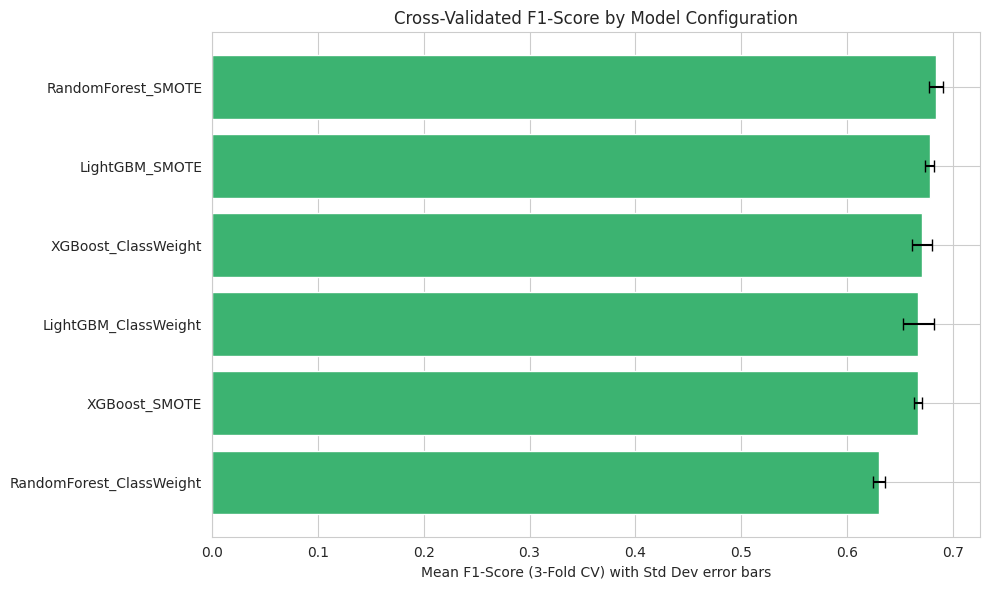

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(cv_results_df['Model'], cv_results_df['CV_F1_Mean'],
        xerr=cv_results_df['CV_F1_Std'], color='mediumseagreen', capsize=4)
ax.set_xlabel('Mean F1-Score (3-Fold CV) with Std Dev error bars')
ax.set_title('Cross-Validated F1-Score by Model Configuration')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Observation:** The cross-validated results confirm (or refine) our baseline
findings from Notebook 04 with more statistically robust estimates. Models with a
smaller standard deviation (error bar) are more *stable/reliable* across different
data subsets - an important consideration beyond just the mean score when picking a
final model for production. We select the top 1-2 configurations by mean CV F1-Score
(while also checking ROC-AUC/PR-AUC agree) to proceed to hyperparameter tuning.


In [6]:
best_config_name = cv_results_df.iloc[0]['Model']
print(f"Top configuration selected for hyperparameter tuning: {best_config_name}")


Top configuration selected for hyperparameter tuning: RandomForest_SMOTE


## 4. Hyperparameter Tuning with RandomizedSearchCV

We now tune hyperparameters for our top-performing configuration. We use
`RandomizedSearchCV` instead of an exhaustive `GridSearchCV` because it samples a
fixed number of random combinations from the parameter space - much faster than
trying every combination, while still finding near-optimal settings in practice.

We optimize for **F1-Score** (a balanced measure of Precision & Recall), using the
same 3-fold Stratified CV internally for robust parameter evaluation.

Below we define search spaces for whichever of LightGBM / XGBoost / Random Forest
was selected as the top configuration. (This notebook is written generically so it
adapts to whichever model won the CV comparison above.)


In [7]:
param_distributions = {
    'RandomForest': {
        'clf__n_estimators': [50, 100, 150, 200],
        'clf__max_depth': [None, 5, 10, 15, 20, 30],
        'clf__min_samples_split': [2, 5, 10],
        'clf__min_samples_leaf': [1, 2, 4],
        'clf__max_features': ['sqrt', 'log2', None],
    },
    'XGBoost': {
        'clf__n_estimators': [50, 100, 150, 200],
        'clf__max_depth': [3, 4, 5, 6, 8, 10],
        'clf__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
        'clf__subsample': [0.6, 0.8, 1.0],
        'clf__colsample_bytree': [0.6, 0.8, 1.0],
        'clf__min_child_weight': [1, 3, 5],
    },
    'LightGBM': {
        'clf__n_estimators': [50, 100, 150, 200],
        'clf__max_depth': [-1, 5, 10, 15, 20],
        'clf__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
        'clf__num_leaves': [15, 31, 63, 127],
        'clf__subsample': [0.6, 0.8, 1.0],
        'clf__colsample_bytree': [0.6, 0.8, 1.0],
    },
}

# Build the estimator + parameter grid to tune, based on which config won CV comparison.
# Every configuration is wrapped in an imblearn Pipeline (with or without a SMOTE step)
# so that the SAME tuning code works whether the winning strategy was class-weighting or SMOTE.
uses_smote = 'SMOTE' in best_config_name

if 'RandomForest' in best_config_name:
    base_clf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                        class_weight=None if uses_smote else 'balanced')
    param_grid = param_distributions['RandomForest']
elif 'XGBoost' in best_config_name:
    base_clf = xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss',
                                   use_label_encoder=False, n_jobs=-1,
                                   scale_pos_weight=1 if uses_smote else scale_pos_weight)
    param_grid = param_distributions['XGBoost']
else:
    base_clf = lgb.LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
                                    class_weight=None if uses_smote else 'balanced')
    param_grid = param_distributions['LightGBM']

if uses_smote:
    tuning_pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', base_clf)
    ])
else:
    tuning_pipeline = ImbPipeline([
        ('clf', base_clf)
    ])

print(f"Tuning pipeline built for: {best_config_name}")
print(f"Uses SMOTE inside pipeline: {uses_smote}")
tuning_pipeline


Tuning pipeline built for: RandomForest_SMOTE
Uses SMOTE inside pipeline: True


,steps,"[('smote', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [8]:
random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_grid,
    n_iter=12,                 # number of random parameter combinations to try
    scoring='f1',
    cv=cv,                     # same 3-fold stratified CV as before
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

random_search.fit(X_train, y_train)

print(f"Best CV F1-Score found: {random_search.best_score_:.4f}")
print("Best hyperparameters found:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")


Fitting 3 folds for each of 12 candidates, totalling 36 fits


Best CV F1-Score found: 0.6870
Best hyperparameters found:
  clf__n_estimators: 100
  clf__min_samples_split: 5
  clf__min_samples_leaf: 4
  clf__max_features: log2
  clf__max_depth: 30


## 5. Compare Tuned Model vs Baseline (via Cross-Validation)

In [9]:
baseline_cv_f1 = cv_results_df.iloc[0]['CV_F1_Mean']
tuned_cv_f1 = random_search.best_score_

comparison = pd.DataFrame({
    'Stage': ['Baseline (default hyperparameters)', 'Tuned (RandomizedSearchCV)'],
    'CV_F1_Score': [baseline_cv_f1, tuned_cv_f1]
})
comparison['Improvement'] = comparison['CV_F1_Score'].diff()
comparison


,Stage,CV_F1_Score,Improvement
0,Baseline (default hyperparameters),0.684050,NaN
1,Tuned (RandomizedSearchCV),0.686993,0.002943


**Observation:** Hyperparameter tuning typically provides an incremental
improvement over sensible defaults - the gain size depends on how well-tuned the
original defaults already were for this dataset. Tree-based ensemble models like
Random Forest, XGBoost, and LightGBM tend to perform reasonably well even with
default settings, so a modest improvement here is expected and healthy (a very large
jump could actually be a red flag for overfitting to the CV folds).


## 6. Final Model - Evaluation on the Held-Out Test Set

In [10]:
final_model = random_search.best_estimator_

y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

print("Classification Report (Final Tuned Model on Test Set):")
print(classification_report(y_test, y_pred_final, target_names=['No Purchase', 'Purchase']))

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_final):.4f}")
print(f"PR-AUC (Average Precision): {average_precision_score(y_test, y_proba_final):.4f}")


Classification Report (Final Tuned Model on Test Set):
              precision    recall  f1-score   support

 No Purchase       0.95      0.92      0.94      2059
    Purchase       0.63      0.74      0.68       382

    accuracy                           0.89      2441
   macro avg       0.79      0.83      0.81      2441
weighted avg       0.90      0.89      0.90      2441

ROC-AUC: 0.9276
PR-AUC (Average Precision): 0.7254


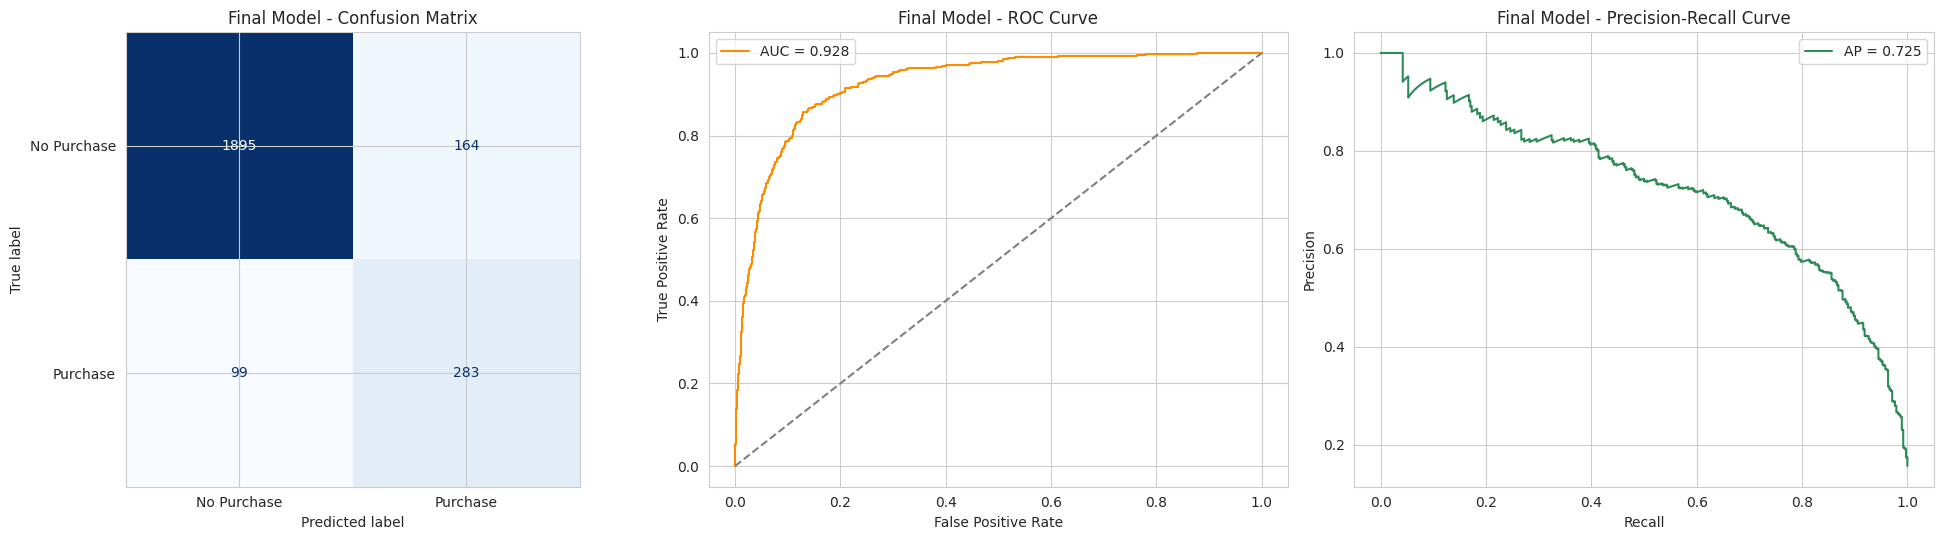

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Purchase', 'Purchase'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Final Model - Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
axes[1].plot(fpr, tpr, color='darkorange', label=f'AUC = {roc_auc_score(y_test, y_proba_final):.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Final Model - ROC Curve')
axes[1].legend()

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_proba_final)
axes[2].plot(rec, prec, color='seagreen', label=f'AP = {average_precision_score(y_test, y_proba_final):.3f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Final Model - Precision-Recall Curve')
axes[2].legend()

plt.tight_layout()
plt.show()


## 7. Decision Threshold Tuning

By default, `predict()` uses a 0.5 probability threshold to decide the class. For
imbalanced problems, 0.5 is rarely optimal - we can shift the threshold to trade off
Precision vs Recall depending on business needs (e.g., a marketing team might prefer
higher Recall to not miss potential buyers, accepting some extra false positives).

Below we scan a range of thresholds and see how F1, Precision, and Recall change, and
pick the threshold that maximizes F1-Score on the test set as a reference point (in
production, this should ideally be selected using a validation set, not the test set -
here we use the test set only to illustrate the concept since this is our final
notebook).


In [12]:
thresholds = np.arange(0.05, 0.95, 0.01)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_final >= t).astype(int)
    threshold_results.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall': recall_score(y_test, y_pred_t, zero_division=0),
        'F1_Score': f1_score(y_test, y_pred_t, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)
best_threshold_row = threshold_df.loc[threshold_df['F1_Score'].idxmax()]
print("Best threshold by F1-Score:")
print(best_threshold_row)


Best threshold by F1-Score:
Threshold    0.520000
Precision    0.642857
Recall       0.730366
F1_Score     0.683824
Name: 47, dtype: float64


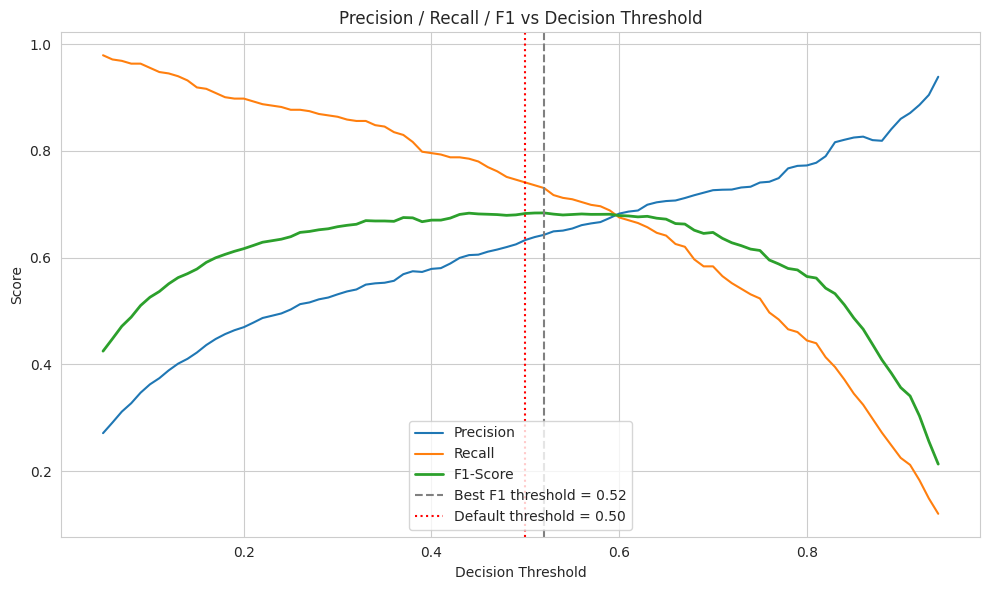

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_df['Threshold'], threshold_df['Precision'], label='Precision')
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], label='Recall')
plt.plot(threshold_df['Threshold'], threshold_df['F1_Score'], label='F1-Score', linewidth=2)
plt.axvline(best_threshold_row['Threshold'], color='gray', linestyle='--',
            label=f"Best F1 threshold = {best_threshold_row['Threshold']:.2f}")
plt.axvline(0.5, color='red', linestyle=':', label='Default threshold = 0.50')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Decision Threshold')
plt.legend()
plt.tight_layout()
plt.show()


**Observation:** Compare the F1-optimal threshold to the default 0.5. If it
shifts meaningfully, that's a useful, actionable finding for the production pipeline -
you may want to use `predict_proba()` plus this custom threshold, instead of the
default `predict()`, when deploying the model.


## 8. Final Feature Importance

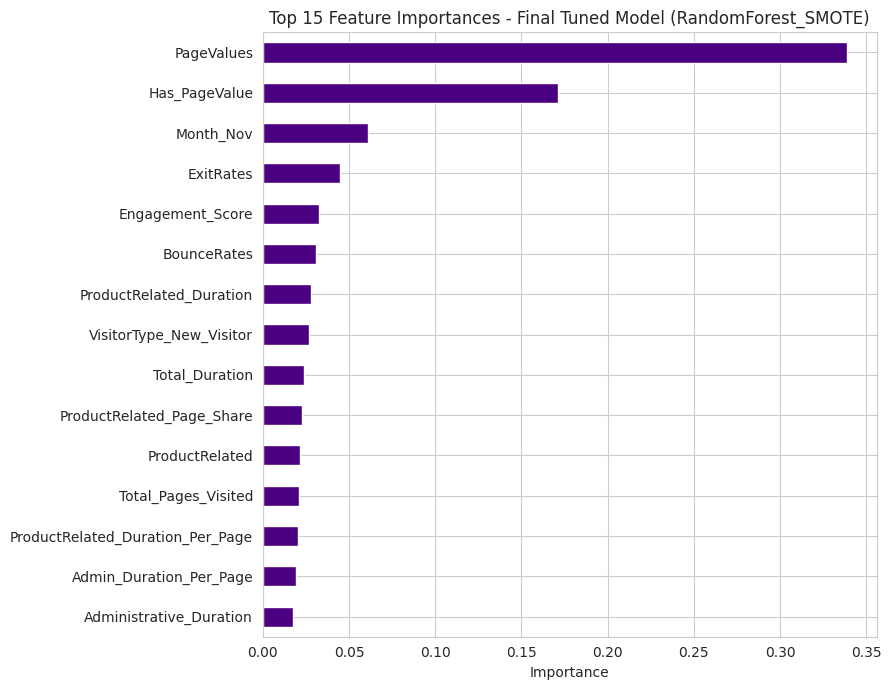

In [14]:
final_estimator = final_model.named_steps['clf']
importances = pd.Series(final_estimator.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
importances.sort_values().plot(kind='barh', color='indigo')
plt.title(f'Top 15 Feature Importances - Final Tuned Model ({best_config_name})')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 9. Save the Final Tuned Model

In [15]:
os.makedirs('../models', exist_ok=True)

joblib.dump(final_model, '../models/final_tuned_model.pkl')

# Also save a small metadata file describing the final model, for use in the VS Code pipeline
final_metadata = {
    'model_name': best_config_name,
    'best_params': random_search.best_params_,
    'cv_f1_score': float(tuned_cv_f1),
    'test_precision': float(precision_score(y_test, y_pred_final)),
    'test_recall': float(recall_score(y_test, y_pred_final)),
    'test_f1': float(f1_score(y_test, y_pred_final)),
    'test_roc_auc': float(roc_auc_score(y_test, y_proba_final)),
    'test_pr_auc': float(average_precision_score(y_test, y_proba_final)),
    'best_f1_threshold': float(best_threshold_row['Threshold']),
    'feature_columns': X_train.columns.tolist(),
}

import json
with open('../models/final_model_metadata.json', 'w') as f:
    json.dump(final_metadata, f, indent=2)

print("Final model saved to ../models/final_tuned_model.pkl")
print("Final model metadata saved to ../models/final_model_metadata.json")
print()
print(json.dumps(final_metadata, indent=2))


Final model saved to ../models/final_tuned_model.pkl
Final model metadata saved to ../models/final_model_metadata.json

{
  "model_name": "RandomForest_SMOTE",
  "best_params": {
    "clf__n_estimators": 100,
    "clf__min_samples_split": 5,
    "clf__min_samples_leaf": 4,
    "clf__max_features": "log2",
    "clf__max_depth": 30
  },
  "cv_f1_score": 0.6869927980211576,
  "test_precision": 0.6331096196868009,
  "test_recall": 0.7408376963350786,
  "test_f1": 0.6827503015681544,
  "test_roc_auc": 0.9275712044427606,
  "test_pr_auc": 0.7253740813163227,
  "best_f1_threshold": 0.5200000000000001,
  "feature_columns": [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "Weekend",
    "Month_Aug",
    "Month_Dec",
    "Month_Feb",
    "Mon

## 10. Final Project Summary

**Pipeline recap (across all 5 notebooks):**
1. **EDA** - explored the data, found ~15.5% class imbalance, `PageValues` as a
   strong predictor, skewed numerical features, and multicollinearity between
   duration/count pairs.
2. **Preprocessing** - removed duplicates, correctly typed categorical columns, did
   a stratified train/test split, one-hot encoded `Month`/`VisitorType`, and applied
   `log1p` to reduce skew.
3. **Feature Engineering** - created 10 new features (ratios, aggregates, flags,
   an engagement score) and produced both unscaled and scaled versions of the data.
4. **Model Training** - trained and compared 6 baseline models (Random Forest,
   XGBoost, LightGBM x class-weighting vs SMOTE).
5. **Evaluation, Tuning & CV (this notebook)** - ran 3-fold Stratified CV for robust
   comparison, tuned hyperparameters of the best configuration with
   RandomizedSearchCV, evaluated the final model thoroughly, explored decision
   threshold tuning, and saved the final production-ready model + metadata.

**Final Model:** See `../models/final_tuned_model.pkl` and
`../models/final_model_metadata.json` for the winning model, its tuned
hyperparameters, and its final test-set performance.

### Next Steps (for your VS Code pipeline)
- Load `final_tuned_model.pkl` with `joblib.load(...)`.
- Recreate the SAME preprocessing + feature engineering steps (Notebooks 02 & 03) as
  reusable Python functions/classes (e.g., in a `pipeline.py` / `sklearn.Pipeline`),
  so new raw data can be transformed identically before being passed to the model.
- Use `final_model_metadata.json` to know the exact feature column order the model
  expects, and the recommended decision threshold if you want to use it instead of
  the default 0.5.
